In [3]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


#avoid warning messages
import warnings
warnings.filterwarnings('ignore')

In [4]:
# read dataset from a public Google Drive File

file_link = 'https://drive.google.com/file/d/1LnU6moeljyBUx0YKrk4LzhS7JEdpnL4e/view?usp=sharing'

# get the id part of the file
id = file_link.split("/")[-2]

# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

# let's look at the first few instances
df.head()

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,loam,5.192294,bi-weekly,chemical,31.719602,61.591861,0
1,sandy,4.033133,weekly,organic,28.919484,52.422276,1
2,loam,8.892769,bi-weekly,none,23.179059,44.660539,0
3,loam,8.241144,bi-weekly,none,18.465886,46.433227,0
4,sandy,8.374043,bi-weekly,organic,NaN,63.625923,0


In [5]:
df.shape

(193, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Soil_Type         193 non-null    object 
 1   Sunlight_Hours    191 non-null    float64
 2   Water_Frequency   192 non-null    object 
 3   Fertilizer_Type   192 non-null    object 
 4   Temperature       183 non-null    float64
 5   Humidity          191 non-null    float64
 6   Growth_Milestone  193 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 10.7+ KB


In [7]:
df.describe(include='all')

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
count,193,191.000000,192,192,183.000000,191.000000,193.000000
unique,3,NaN,3,3,NaN,NaN,NaN
top,clay,NaN,daily,none,NaN,NaN,NaN
freq,67,NaN,73,74,NaN,NaN,NaN
mean,NaN,6.814887,NaN,NaN,25.017731,58.086350,0.497409
std,NaN,1.603823,NaN,NaN,5.363576,12.696306,0.501294
min,NaN,4.033133,NaN,NaN,15.200000,30.567682,0.000000
25%,NaN,5.464666,NaN,NaN,20.599339,49.056490,0.000000
50%,NaN,6.832000,NaN,NaN,25.912336,59.182806,0.000000
75%,NaN,8.252072,NaN,NaN,29.496670,69.150000,1.000000


In [8]:
df.nunique()

,0
Soil_Type,3
Sunlight_Hours,188
Water_Frequency,3
Fertilizer_Type,3
Temperature,180
Humidity,189
Growth_Milestone,2


In [9]:
df.isnull().sum()

,0
Soil_Type,0
Sunlight_Hours,2
Water_Frequency,1
Fertilizer_Type,1
Temperature,10
Humidity,2
Growth_Milestone,0


In [10]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Soil_Type', 'Water_Frequency', 'Fertilizer_Type']
Numerical Variables:
['Sunlight_Hours', 'Temperature', 'Humidity', 'Growth_Milestone']


Growth_Milestone
0    97
1    96
Name: count, dtype: int64


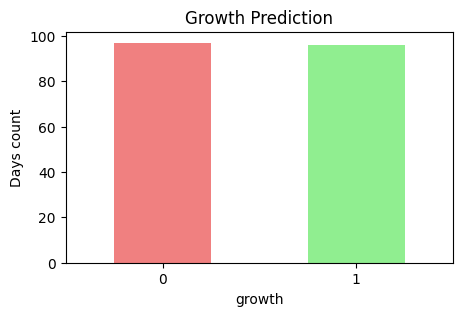

In [11]:
# Visualize the distribution of the 'Growth_Milestone' variable

print(df.value_counts('Growth_Milestone'))

plt.figure(figsize=(5, 3))
df['Growth_Milestone'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Growth Prediction')
plt.xlabel('growth')
plt.ylabel('Days count')
plt.xticks(rotation = 0)
plt.show()

<Figure size 800x600 with 0 Axes>

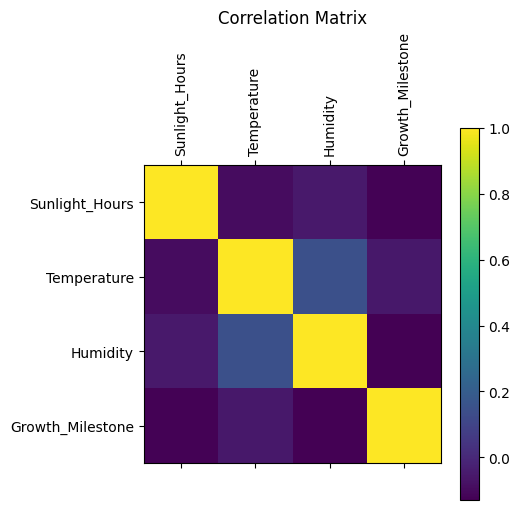

In [12]:
# Correlation matrix plot
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)
# print(correlation_matrix)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

In [13]:
df= df.drop_duplicates()
df

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,loam,5.192294,bi-weekly,chemical,31.719602,61.591861,0
1,sandy,4.033133,weekly,organic,28.919484,52.422276,1
2,loam,8.892769,bi-weekly,none,23.179059,44.660539,0
3,loam,8.241144,bi-weekly,none,18.465886,46.433227,0
4,sandy,8.374043,bi-weekly,organic,NaN,63.625923,0
...,...,...,...,...,...,...,...
188,sandy,5.652000,daily,none,28.000000,70.200000,0
189,clay,7.528000,weekly,chemical,30.500000,60.100000,1
190,loam,4.934000,bi-weekly,none,24.500000,61.700000,0
191,sandy,8.273000,daily,organic,27.900000,69.500000,1


In [15]:
df.dropna(subset=['Fertilizer_Type','Temperature','Humidity','Water_Frequency','Sunlight_Hours','Soil_Type' ], inplace=True)
df

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,loam,5.192294,bi-weekly,chemical,31.719602,61.591861,0
1,sandy,4.033133,weekly,organic,28.919484,52.422276,1
2,loam,8.892769,bi-weekly,none,23.179059,44.660539,0
3,loam,8.241144,bi-weekly,none,18.465886,46.433227,0
5,sandy,8.627622,bi-weekly,none,20.004858,67.618726,0
...,...,...,...,...,...,...,...
187,loam,6.127000,bi-weekly,organic,22.100000,55.700000,1
188,sandy,5.652000,daily,none,28.000000,70.200000,0
189,clay,7.528000,weekly,chemical,30.500000,60.100000,1
190,loam,4.934000,bi-weekly,none,24.500000,61.700000,0


In [21]:

df['Sunlight_Hours'].fillna(df['Sunlight_Hours'].mean(), inplace=True)
df['Humidity'].fillna(df['Humidity'].mean(), inplace=True)
df['Temperature'].fillna(df['Temperature'].mean(), inplace=True)
df

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,loam,5.192294,bi-weekly,chemical,31.719602,61.591861,0
1,sandy,4.033133,weekly,organic,28.919484,52.422276,1
2,loam,8.892769,bi-weekly,none,23.179059,44.660539,0
3,loam,8.241144,bi-weekly,none,18.465886,46.433227,0
5,sandy,8.627622,bi-weekly,none,20.004858,67.618726,0
...,...,...,...,...,...,...,...
187,loam,6.127000,bi-weekly,organic,22.100000,55.700000,1
188,sandy,5.652000,daily,none,28.000000,70.200000,0
189,clay,7.528000,weekly,chemical,30.500000,60.100000,1
190,loam,4.934000,bi-weekly,none,24.500000,61.700000,0


In [22]:
df.shape

(177, 7)

In [23]:
df.isnull().sum()

,0
Soil_Type,0
Sunlight_Hours,0
Water_Frequency,0
Fertilizer_Type,0
Temperature,0
Humidity,0
Growth_Milestone,0


In [24]:
#check for categorical and numerical variables in df
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Soil_Type', 'Water_Frequency', 'Fertilizer_Type']
Numerical Variables:
['Sunlight_Hours', 'Temperature', 'Humidity', 'Growth_Milestone']


In [25]:
df = pd.get_dummies(df, columns=['Soil_Type', 'Water_Frequency', 'Fertilizer_Type'])
df.isnull().sum()
df.shape

(177, 13)

In [26]:
df.head()

,Sunlight_Hours,Temperature,Humidity,Growth_Milestone,Soil_Type_clay,Soil_Type_loam,Soil_Type_sandy,Water_Frequency_bi-weekly,Water_Frequency_daily,Water_Frequency_weekly,Fertilizer_Type_chemical,Fertilizer_Type_none,Fertilizer_Type_organic
0,5.192294,31.719602,61.591861,0,False,True,False,True,False,False,True,False,False
1,4.033133,28.919484,52.422276,1,False,False,True,False,False,True,False,False,True
2,8.892769,23.179059,44.660539,0,False,True,False,True,False,False,False,True,False
3,8.241144,18.465886,46.433227,0,False,True,False,True,False,False,False,True,False
5,8.627622,20.004858,67.618726,0,False,False,True,True,False,False,False,True,False


In [27]:
df.shape

(177, 13)

Implementing AdaBoost using Scikit-learn Library

In [30]:
# Split the data into 80-20 train-test split (you can do other ratios as well)
X = df.drop(['Growth_Milestone'], axis=1)
# df['RainTomorrow']= df['RainTomorrow'].replace(0, -1)
y = df['Growth_Milestone']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# display the shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (141, 12)
X_test shape: (36, 12)
y_train shape: (141,)
y_test shape: (36,)


In [40]:
from sklearn.ensemble import AdaBoostClassifier

# Define parameter values
n_estimators_list = [5, 10, 15]
learning_rate_list = [0.1, 0.3, 0.4]

# Loop through all combinations of n_estimators and learning_rate
for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        # Initialize and fit the AdaBoostClassifier with current parameters
        abc = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
        model = abc.fit(X_train, y_train)

        # Calculate training and validation accuracy
        training_accuracy = model.score(X_train, y_train)
        validation_accuracy = model.score(X_test, y_test)

        # Print the results
        print(f"n_estimators: {n_estimators}, learning_rate: {learning_rate}, "
              f"Training Accuracy: {training_accuracy:.3f}, Validation Accuracy: {validation_accuracy:.3f}")



n_estimators: 5, learning_rate: 0.1, Training Accuracy: 0.716, Validation Accuracy: 0.611
n_estimators: 5, learning_rate: 0.3, Training Accuracy: 0.709, Validation Accuracy: 0.611
n_estimators: 5, learning_rate: 0.4, Training Accuracy: 0.709, Validation Accuracy: 0.611
n_estimators: 10, learning_rate: 0.1, Training Accuracy: 0.709, Validation Accuracy: 0.611
n_estimators: 10, learning_rate: 0.3, Training Accuracy: 0.716, Validation Accuracy: 0.528
n_estimators: 10, learning_rate: 0.4, Training Accuracy: 0.709, Validation Accuracy: 0.500
n_estimators: 15, learning_rate: 0.1, Training Accuracy: 0.709, Validation Accuracy: 0.528
n_estimators: 15, learning_rate: 0.3, Training Accuracy: 0.730, Validation Accuracy: 0.667
n_estimators: 15, learning_rate: 0.4, Training Accuracy: 0.730, Validation Accuracy: 0.611
